## Q3.Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Feature engineering
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month-end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


## Train - Test

In [3]:
# Sort by date
df = df.sort_values('transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


## Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [5]:
target = 'items_sold'

categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [
    'store_id',
    'competition_density',
    'is_weekend',
    'is_festival',
    'year',
    'month',
    'day_of_week',
    'is_month_end'
]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## Model Training 

In [7]:
X_train = train_df[numerical_features + categorical_features]
y_train = train_df[target]

X_test = test_df[numerical_features + categorical_features]
y_test = test_df[target]

## Linnear Regression 

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

lin_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lin_model.fit(X_train, y_train)

y_pred_lr = lin_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890622
Linear Regression MAE: 21.05292667458839


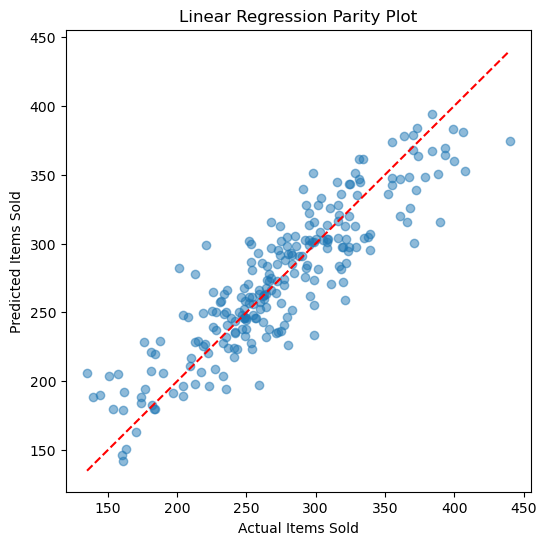

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Linear Regression Parity Plot")
plt.show()

## Random Forest

In [10]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.759396836576624
Random Forest MAE: 24.23754166666667


## Feature Importance

In [11]:
# Get feature names after encoding
cat_features_encoded = rf_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

all_features = numerical_features + list(cat_features_encoded)

In [12]:
import pandas as pd

importances = rf_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

                feature  importance
3           is_festival    0.173356
18     store_size_small    0.166052
15  location_type_urban    0.108783
6           day_of_week    0.078710
2            is_weekend    0.068935
0              store_id    0.054827
13  location_type_rural    0.052722
1   competition_density    0.050903
16     store_size_large    0.050092
5                 month    0.037521


In [13]:
top5 = feature_importance_df.head(5)
print("Top 5 Features:\n", top5)

Top 5 Features:
                 feature  importance
3           is_festival    0.173356
18     store_size_small    0.166052
15  location_type_urban    0.108783
6           day_of_week    0.078710
2            is_weekend    0.068935
